In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [143]:
data_path = Path('data/E_Commerce_Cleaned.csv')
df = pd.read_csv(data_path)

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 35 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   CustomerID                              5630 non-null   int64  
 1   Churn                                   5630 non-null   int64  
 2   Tenure                                  5630 non-null   float64
 3   CityTier                                5630 non-null   int64  
 4   WarehouseToHome                         5630 non-null   float64
 5   HourSpendOnApp                          5630 non-null   float64
 6   NumberOfDeviceRegistered                5630 non-null   int64  
 7   SatisfactionScore                       5630 non-null   int64  
 8   NumberOfAddress                         5630 non-null   int64  
 9   Complain                                5630 non-null   int64  
 10  OrderAmountHikeFromlastYear             5630 non-null   float64
 11  Co

In [145]:
df.sample(5)

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_is_missing,WarehouseToHome_is_missing,HourSpendOnApp_is_missing,OrderAmountHikeFromlastYear_is_missing,CouponUsed_is_missing,OrderCount_is_missing,DaySinceLastOrder_is_missing,PreferredLoginDevice_Phone,PreferredPaymentMode_COD,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,PreferedOrderCat_Phone,MaritalStatus_Married,MaritalStatus_Single
3408,53409,0,19.0,1,30.0,3.0,4,5,3,1,16.0,2.0,2.0,9.0,161.33,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2440,52441,0,6.0,1,34.0,3.0,3,3,2,1,12.0,4.0,5.0,7.0,152.07,0,0,0,0,0,0,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1548,51549,0,13.0,1,25.0,3.0,3,1,9,1,15.0,3.0,3.0,7.0,127.41,0,0,1,0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4708,54709,0,17.0,3,22.0,3.0,5,1,5,0,19.0,2.0,3.0,3.0,193.04,0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
481,50482,0,7.0,1,14.0,3.0,4,2,2,0,16.0,1.0,1.0,3.0,125.53,0,1,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


Text(0.5, 1.0, 'Original Class Distribution')

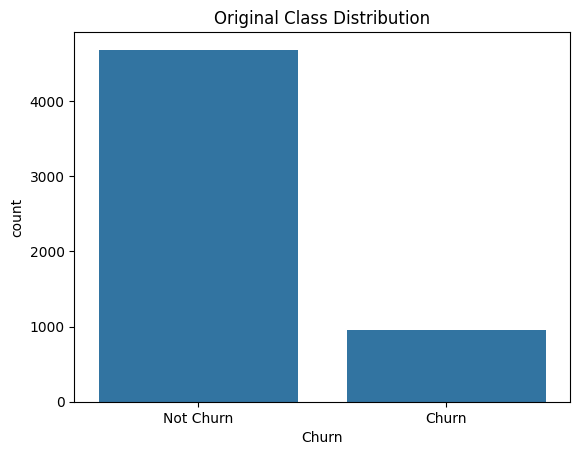

In [146]:
sns.countplot(data=df, x='Churn')
plt.xticks([0, 1], ['Not Churn', 'Churn'])
plt.title('Original Class Distribution')

In [147]:
X = df.drop(columns=['CustomerID','Churn'])  
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [148]:
smote=SMOTE(sampling_strategy='minority',random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

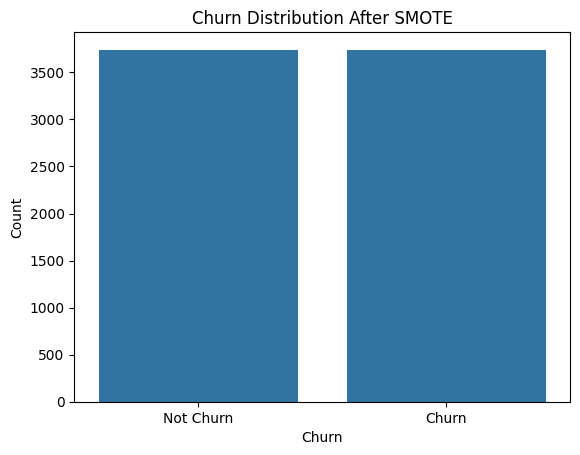

In [149]:
counts_sm = y_train_sm.value_counts()
sns.barplot(x=counts_sm.index, y=counts_sm.values)
plt.xticks([0,1],['Not Churn', 'Churn'])
plt.ylabel("Count")
plt.xlabel('Churn')
plt.title("Churn Distribution After SMOTE")
plt.show()

In [150]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [151]:
classifier=RandomForestClassifier(n_estimators=100,random_state=42)
classifier.fit(X_train_scaled,y_train_sm)
y_pred=classifier.predict(X_test_scaled)

In [152]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')


Accuracy: 96.18%


In [153]:
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'{classification_report(y_test,y_pred)}')

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       941
           1       0.95      0.81      0.87       185

    accuracy                           0.96      1126
   macro avg       0.96      0.90      0.93      1126
weighted avg       0.96      0.96      0.96      1126



<Axes: >

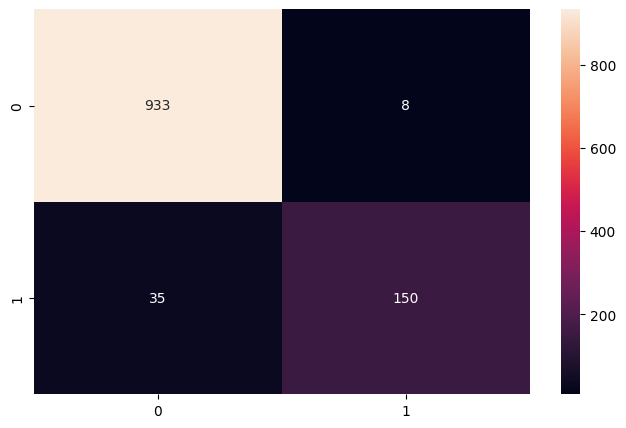

In [154]:
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix,annot=True,fmt='g',)

In [155]:
Path('../models').mkdir(exist_ok=True)

In [156]:
joblib.dump(classifier, '../models/classifier_model.pkl')

['../models/classifier_model.pkl']

In [157]:
log_reg=LogisticRegression(random_state=42,max_iter=100)
log_reg.fit(X_train_scaled,y_train_sm)
y_pred=log_reg.predict(X_test_scaled)

In [158]:
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f'{classification_report(y_test,y_pred)}')



Accuracy: 78.33%
              precision    recall  f1-score   support

           0       0.96      0.78      0.86       941
           1       0.42      0.82      0.55       185

    accuracy                           0.78      1126
   macro avg       0.69      0.80      0.71      1126
weighted avg       0.87      0.78      0.81      1126



In [159]:
report_dict=classification_report(y_test,y_pred,output_dict=True)
lr_precision = report_dict['1']['precision']
lr_recall = report_dict['1']['recall']
lr_f1 = report_dict['1']['f1-score']
lr_data = pd.DataFrame({
    'Metrics': ['Precision', 'Recall', 'F1-score'], 
    'Values': [lr_precision, lr_recall, lr_f1]
})

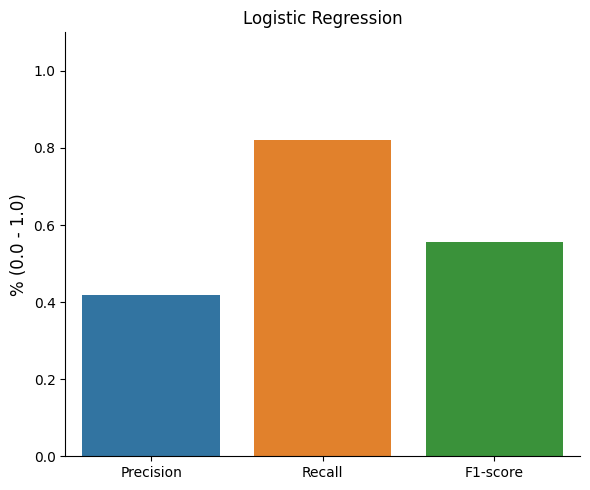

In [160]:
plt.figure(figsize=(6, 5))
sns.barplot(data=lr_data,x='Metrics',y='Values',hue='Metrics')
plt.title('Logistic Regression')
plt.ylim(0, 1.1)  
plt.ylabel('% (0.0 - 1.0)', fontsize=12)
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

In [161]:
joblib.dump(log_reg, '../models/LogisticRegression_model.pkl')

['../models/LogisticRegression_model.pkl']

In [162]:
gbc=GradientBoostingClassifier(random_state=42,n_estimators=100)
gbc.fit(X_train_scaled,y_train_sm)
y_pred=gbc.predict(X_test_scaled)


In [163]:
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f'{classification_report(y_test,y_pred)}')

Accuracy: 91.12%
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       941
           1       0.74      0.70      0.72       185

    accuracy                           0.91      1126
   macro avg       0.84      0.83      0.83      1126
weighted avg       0.91      0.91      0.91      1126



In [164]:
report_dict_gbc=classification_report(y_test, y_pred, output_dict=True)
gbc_precision = report_dict_gbc['1']['precision']
gbc_recall = report_dict_gbc['1']['recall']
gbc_f1 = report_dict_gbc['1']['f1-score']
gbc_data = pd.DataFrame({
    'Metrics': ['Precision', 'Recall', 'F1-score'], 
    'Values': [gbc_precision, gbc_recall, gbc_f1]
})

In [165]:
gbc_data

,Metrics,Values
0,Precision,0.742857
1,Recall,0.702703
2,F1-score,0.722222


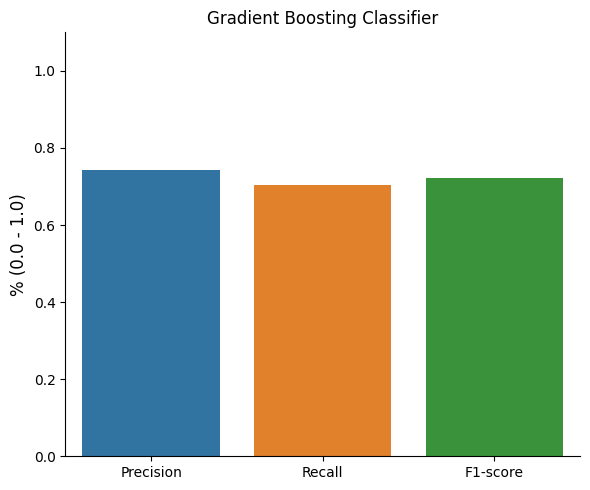

In [166]:
plt.figure(figsize=(6, 5))
sns.barplot(data=gbc_data,x='Metrics',y='Values',hue='Metrics')
plt.title('Gradient Boosting Classifier')
plt.ylim(0, 1.1)  
plt.ylabel('% (0.0 - 1.0)', fontsize=12)
plt.xlabel('')
sns.despine()
plt.tight_layout()
plt.show()

In [167]:
joblib.dump(gbc, '../models/GradientBoostingClassifier_model.pkl')

['../models/GradientBoostingClassifier_model.pkl']